In [33]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

from contextlib import nullcontext

from datetime import datetime

In [40]:
api = wandb.Api()

In [41]:
EXPERIMENT_GROUP = "./artifacts/2023-10-s17/experiments/ex1-prca-logit-modifiers"

In [43]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    training_size,
    use_val_split,
    logit_modifier,
    contamination_level,
    verbose=False,
    
):
    
    assert use_val_split

    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.contamination_level": contamination_level},
            {"config.use_val_split": use_val_split},
            {"config.logit_modifier_name": logit_modifier}
#             {"config.seed": 1},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics"in run.summary:
            print(">> bad run config")
            print(run.config)
            count += 1
            return run
            continue
                     
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        datasets.append(run.config["dataset"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                # remark: this is the actual value used in distillation
                # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                lambda_layer=run.config["policy_lambda_layer"],
                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"]
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)

        
        
    df = df.groupby(by="lambda_layer").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
        
    np.testing.assert_allclose(
        df["val_acc"]["count"], 3
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="basis-identity:prca-sortabs--uncentered",
    logit_modifier="difftop2winners",
    training_size=1.0,
    verbose=True,
    contamination_level=0.0,
    use_val_split=True
)

summary

we have 39 runs
df.shape: (13, 11)


lambda_layer   val_acc                 val_agreement                  \
                       mean       std count          mean       std count   
0        0.000000  0.488310  0.010087     3      0.487642  0.009037     3   
1        0.000001  0.511690  0.021983     3      0.510354  0.022346     3   
2        0.000010  0.505010  0.019326     3      0.503674  0.018941     3   
3        0.000100  0.494322  0.014218     3      0.494322  0.015566     3   
4        0.001000  0.503674  0.021050     3      0.502338  0.022074     3   
5        0.010000  0.513694  0.003061     3      0.513026  0.003471     3   
6        0.100000  0.521042  0.033112     3      0.520374  0.034147     3   
7        1.000000  0.596526  0.021050     3      0.595190  0.022044     3   
8       10.000000  0.619238  0.019326     3      0.617902  0.020470     3   
9      100.000000  0.635271  0.023111     3      0.633935  0.024242     3   
10    1000.000000  0.640615  0.006442     3      0.639279  0.007226     3   
11   10000.000000  0.644623  0.010284     3      0.643287  0.010604     3   
12  100000.000000  0.635939  0.012080     3      0.634603  0.013039     3   

   val_agreement_on_teacher_correct                 teacher_acc  
                               mean       std count        mean  
0                          0.487642  0.009037     3    0.998664  
1                          0.510354  0.022346     3    0.998664  
2                          0.503674  0.018941     3    0.998664  
3                          0.493654  0.015306     3    0.998664  
4                          0.502338  0.022074     3    0.998664  
5                          0.513026  0.003471     3    0.998664  
6                          0.520374  0.034147     3    0.998664  
7                          0.595190  0.022044     3    0.998664  
8                          0.617902  0.020470     3    0.998664  
9                          0.633935  0.024242     3    0.998664  
10                         0.639279  0.007226     3    0.998664  
11                         0.643287  0.010604     3    0.998664  
12                         0.634603  0.013039     3    0.998664

# Comparison on `cifar100-resnet18-v1`

student: resnet18xscifarcompr1
experiment group: ./artifacts/2023-10-s17/experiments/ex1-prca-logit-modifiers
date: 2023-10-17 11:37:35.980940


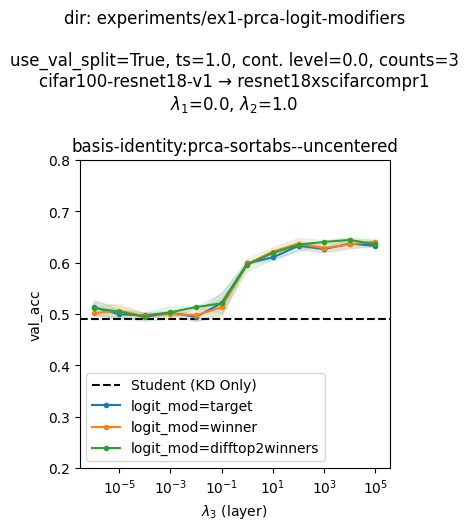

In [45]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    return policy \
        .replace("basis-identity", "id") \
        .replace("uncentered", "uncent.")

    
def viz_distillation(
    teacher, student,
    arr_logit_modifiers,
    show_legend=True,
    contamination_level=0.0
):

    policy = "basis-identity:prca-sortabs--uncentered"
    
    training_size = 1.0
    use_val_split = True
    lambda_kd = 1.0
    lambda_task = 0.0
            
    col = "val_acc"
    
    ncols = 1
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
    
    print("============")
    print(f"student: {student}")
    print(f"experiment group: {EXPERIMENT_GROUP}")
    print(f"date: {datetime.now()}")
    
    for mix, logit_modifier in enumerate(arr_logit_modifiers):

        df = read_data(
            logit_modifier=logit_modifier,

            teacher=teacher,
            student=student,
            policy=policy,
            lambda_task=lambda_task,
            lambda_kd=lambda_kd,
            training_size=training_size,
            contamination_level=contamination_level,
            use_val_split=use_val_split,
            verbose=False
        )

        
        if mix > 0:
            np.testing.assert_allclose(
                acc_student_kd_only,
                df[col]["mean"].values[0],
                atol=1e-2
            )
        else:
            acc_student_kd_only = df[col]["mean"].values[0]
#             plt.axhline(
#                 df["teacher_acc"].values[-1],
#                 ls="-",
#                 color="k",
#                 label="Teacher"
#             )
            plt.axhline(
                acc_student_kd_only,
                ls="--",
                color="k",
                label="Student (KD Only)"
            )


#             plt.axhline(0.2, ls="--", color="lightgray", label="Random")
        
        # here, we use [1:] to excluding lambda_layer=0
        count = df[col]["count"].values[-1]
        assert df["lambda_layer"][0] == 0.0
        ticks = df["lambda_layer"][1:]
        mean = df[col]["mean"][1:]
        stderr = df[col]["std"][1:] / (count ** 0.5)
        
        plt.plot(
            ticks,
            mean,
            marker=".",
            label=f"logit_mod={logit_modifier}"
        )
        
        plt.fill_between(
            ticks,
            mean - stderr,
            mean + stderr,
            alpha=0.1,
            color=plt.gca().lines[-1].get_color()
        )
        

    plt.xscale("log")
    plt.xlabel("$\lambda_3$ (layer)")
    plt.ylabel(col)
    plt.legend()
    plt.ylim([0.2, 0.8])
            
    plt.title(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"use_val_split={use_val_split}, ts={training_size}, cont. level={contamination_level}, counts={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
            "",
            policy,
        ]),
        y=1.0,
    )
    


viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    arr_logit_modifiers=[
        "target",
        "winner",
        "difftop2winners"
    ]
)

# Summary

*Setup*: `dataset=cifar100-people, teacher=cifar100-resnet18-v1, student=resnet18xscifarcompr1`

*Aims:* investigate the influence of logit modifiers on distillation performance.

*Conclusion:* distillation with `logit_mod=difftop2winners` leads to slighly better performance.